In [15]:
"""
plot_change_vs_r2.py
--------------------
Scatter plot: mean synaptic change rate (X) vs mean R² (Y) across learned plasticity rules.

Each path in DATA_PATHS corresponds to one learned rule containing 10 networks (k=0..9).
X: mean |ΔW_ij| / |W_ij| averaged over the last LAST_N_EPOCHS epochs and all nets.
Y: mean R² ± std across 10 nets, computed from last 100 prediction steps.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

# ── helpers you already have ──────────────────────────────────────────────────
# Replace these stubs with your actual imports, e.g.:
#   from your_module import load_numpy, load_targets_and_predictions, format_plot

def load_numpy(path):
    return np.load(path)

def load_targets_and_predictions(dp, net_file, last_n=100):
    targets     = np.load(os.path.join(dp, f'targets/{net_file}'))
    predictions = np.load(os.path.join(dp, f'predictions/{net_file}'))
    return targets[-last_n * 120:], predictions[-last_n * 120:]

def format_plot(axs):
    for ax in np.atleast_1d(axs):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# ── constants – adjust to match your codebase ─────────────────────────────────
CELL_TYPE_1_SIZE = 5   # adjust as needed

# ── tuneable parameter ────────────────────────────────────────────────────────
LAST_N_EPOCHS = 50      # ← change this to use fewer/more final epochs for X axis

# ── data paths ────────────────────────────────────────────────────────────────
DATA_PATHS = [
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001100_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:23.644770_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001101_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.297833_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001102_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:18.591026_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.167434_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001104_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_11:32:44.289360_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001105_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.167432_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001106_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.547200_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001107_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.547200_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001108_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.547200_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001110_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.025293_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001111_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.025289_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001112_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.025292_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001113_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_11:32:47.779433_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001114_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_11:32:33.150402_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001115_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_11:32:33.021471_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001116_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_11:32:35.377599_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001117_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_11:32:33.552182_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001118_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:23.162271_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:23.318062_run_None',
]

DATA_PATHS_TWO_FACTOR = [
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001300_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.672367_run_None',
    # 'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001301_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:30.899455_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001302_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:30.836464_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001303_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.255004_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001304_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.065713_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001305_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.014065_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001306_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.462472_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001307_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.197715_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001308_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.182974_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001309_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.411327_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001310_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.396294_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001311_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:30.641092_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001312_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.278979_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001313_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:33.791682_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001314_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.365755_run_None',
    # 'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001315_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.001664_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001316_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.065773_run_None',
    # 'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001317_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:30.999282_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001318_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.533370_run_None',
    'sims_out/n5_long_two_factor_min_pactive_0p25_diag_small_bump_test_001319_1.0_inp_0.27_het_0.0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-01_10:10:31.353745_run_None',
]
N_NETS = 10   # k = 0 .. 9


# ── data loading ──────────────────────────────────────────────────────────────

def compute_change_rate_for_net(dp, k, last_n=LAST_N_EPOCHS):
    """
    Mean normalised |ΔW| / |W| over the last `last_n` epoch transitions for net k.
    Returns a scalar.
    """
    all_w = load_numpy(os.path.join(dp, f'weights/net_00{k}.npy')).squeeze()
    all_w_trimmed = all_w[:, :CELL_TYPE_1_SIZE, :CELL_TYPE_1_SIZE]
    diffs  = np.abs(all_w_trimmed[1:] - all_w_trimmed[:-1])
    denoms = np.abs(all_w_trimmed[:-1])
    normed_diffs = np.nanmean(diffs / denoms, axis=(1, 2))  # shape: (n_epochs-1,)
    return float(np.nanmean(normed_diffs[-last_n:]))


def compute_r2_for_net(dp, k):
    """R² for net k, evaluated on last 100 prediction steps."""
    targets, predictions = load_targets_and_predictions(dp, f'net_00{k}.npy', last_n=100)
    t = targets[119::120]
    p = predictions[119::120]
    ss_res = np.sum((t - p) ** 2)
    ss_tot = np.sum((t - t.mean()) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def collect_data(data_paths, last_n=LAST_N_EPOCHS):
    """
    Returns arrays of shape (n_rules,) for mean X, std X, mean Y, std Y.
    """
    mean_x, std_x = [], []
    mean_y, std_y = [], []

    for dp in data_paths:
        rates = [compute_change_rate_for_net(dp, k, last_n) for k in range(N_NETS)]
        r2s   = [compute_r2_for_net(dp, k)                  for k in range(N_NETS)]

        rates = np.array(rates)
        r2s   = np.array(r2s)

        mean_x.append(np.nanmean(rates));  std_x.append(np.nanstd(rates))
        mean_y.append(np.nanmean(r2s));    std_y.append(np.nanstd(r2s))

        print(f"Rule {os.path.basename(dp)[-6:]}  "
              f"change_rate={mean_x[-1]:.4e}±{std_x[-1]:.2e}  "
              f"R²={mean_y[-1]:.3f}±{std_y[-1]:.3f}")

    return (np.array(mean_x), np.array(std_x),
            np.array(mean_y), np.array(std_y))


# ── plotting ──────────────────────────────────────────────────────────────────

def plot_change_vs_r2(last_n=LAST_N_EPOCHS, save_name=None):
    datasets = [
        (DATA_PATHS,           'steelblue', 'Three-factor'),
        (DATA_PATHS_TWO_FACTOR, 'tomato',   'Two-factor'),
    ]

    scale = 3
    fig, ax = plt.subplots(figsize=(scale, scale))

    for data_paths, color, label in datasets:
        mean_x, std_x, mean_y, std_y = collect_data(data_paths, last_n=last_n)

        ax.errorbar(
            mean_x, mean_y,
            xerr=std_x, yerr=std_y,
            fmt='o',
            ms=5,
            lw=1,
            capsize=3,
            color=color,
            ecolor=color,
            alpha=0.85,
            zorder=3,
            label=label,
        )

    ax.set_xscale('log')
    ax.set_xlabel(
        r'$\left\langle \frac{|\Delta W_{ij}|}{|W_{ij}|} \right\rangle$ '
        f'(last {last_n} epochs)',
        fontsize=9,
    )
    ax.set_ylabel(r'$R^2$', fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, frameon=False)

    format_plot([ax])
    fig.tight_layout()

    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight', dpi=150)
        print(f"Saved to {save_name}")

    plt.show()
    return fig, ax

Rule n_None  change_rate=7.8154e-03±2.32e-03  R²=0.762±0.070
Rule n_None  change_rate=8.0737e-03±1.67e-03  R²=0.759±0.058
Rule n_None  change_rate=3.6914e-03±6.41e-04  R²=0.784±0.053
Rule n_None  change_rate=2.2106e-03±3.11e-04  R²=0.795±0.079
Rule n_None  change_rate=3.2193e-03±4.87e-04  R²=0.747±0.056
Rule n_None  change_rate=8.2957e-03±9.71e-04  R²=0.774±0.051
Rule n_None  change_rate=5.9917e-03±4.66e-04  R²=0.776±0.058
Rule n_None  change_rate=7.6351e-03±1.28e-03  R²=0.776±0.040
Rule n_None  change_rate=2.4810e-03±3.40e-04  R²=0.751±0.078
Rule n_None  change_rate=6.9666e-03±1.01e-03  R²=0.778±0.056
Rule n_None  change_rate=8.3433e-03±6.95e-04  R²=0.792±0.043
Rule n_None  change_rate=3.9386e-03±5.29e-04  R²=0.750±0.056
Rule n_None  change_rate=4.0582e-03±6.43e-04  R²=0.718±0.093
Rule n_None  change_rate=5.5278e-03±1.31e-03  R²=0.726±0.053


/tmp/ipykernel_3495992/2843416598.py:98: RuntimeWarning: invalid value encountered in divide
  normed_diffs = np.nanmean(diffs / denoms, axis=(1, 2))  # shape: (n_epochs-1,)


Rule n_None  change_rate=9.1513e-02±1.61e-02  R²=0.711±0.073
Rule n_None  change_rate=4.4864e-03±9.67e-04  R²=0.732±0.051
Rule n_None  change_rate=4.6733e-03±1.60e-03  R²=0.747±0.126
Rule n_None  change_rate=5.9084e-03±1.12e-03  R²=0.752±0.051
Rule n_None  change_rate=3.2354e-02±3.56e-03  R²=0.888±0.032
Rule n_None  change_rate=2.0940e-02±2.09e-02  R²=0.535±0.141
Rule n_None  change_rate=1.6929e-02±2.16e-03  R²=0.500±0.094
Rule n_None  change_rate=1.7444e-02±7.40e-03  R²=0.579±0.068
Rule n_None  change_rate=2.3964e-02±8.00e-03  R²=0.319±0.148
Rule n_None  change_rate=3.8671e-01±3.92e-02  R²=0.014±0.130
Rule n_None  change_rate=9.5163e-03±4.02e-04  R²=0.681±0.083
Rule n_None  change_rate=3.8550e-02±5.25e-03  R²=0.810±0.143
Rule n_None  change_rate=8.5710e-03±2.59e-03  R²=0.486±0.206
Rule n_None  change_rate=2.2199e-02±5.47e-03  R²=0.885±0.017
Rule n_None  change_rate=1.1182e-02±9.30e-04  R²=0.599±0.120
Rule n_None  change_rate=1.0684e-02±7.51e-04  R²=0.614±0.150
Rule n_None  change_rate

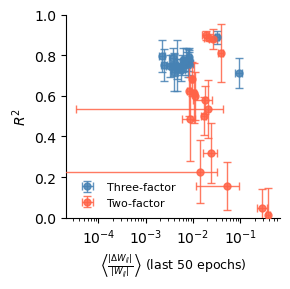

(<Figure size 300x300 with 1 Axes>,
 <Axes: xlabel='$\\left\\langle \\frac{|\\Delta W_{ij}|}{|W_{ij}|} \\right\\rangle$ (last 50 epochs)', ylabel='$R^2$'>)

In [16]:
plot_change_vs_r2(
    last_n=LAST_N_EPOCHS,
    save_name='figures/change_vs_r2.svg',
)